# From predictions to shortlists: a synthetic example

A classifier normally returns one answer, even when several classes look plausible.
Here we use **LAC conformal prediction** to keep a shortlist of possible answers:
automate when exactly one label remains, and send the other cases for review.

We generate three overlapping groups of points, fit a small classifier, and use
separate **calibration examples** to choose which labels to keep. This is a
walk-through of the mechanics, not a coverage study across repeated experiments.

Use a Python kernel with the repository installed. From the repository root,
`pip install -e ".[example,notebook]"` provides the packages needed here.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from conformal_selective_prediction import (
    automated_error_rate,
    automation_rate,
    average_set_size,
    conformal_quantile,
    empirical_coverage,
    lac_prediction_sets,
    lac_scores,
    singleton_mask,
)

## 1. Make a small classification problem

Each point has two numerical features and belongs to one of three classes.
Points are drawn independently from the same fixed distribution; the clouds
overlap, so some examples are genuinely ambiguous.

We reserve separate examples for **training**, **calibration** and **evaluation**.
Only the training examples are used to fit the classifier.

In [2]:
rng = np.random.default_rng(42)
class_centres = np.array([[-2.0, 0.0], [2.0, 0.0], [0.0, 3.0]])
labels = rng.integers(0, 3, size=1200)
noise = rng.normal(scale=1.6, size=(1200, 2))
features = class_centres[labels] + noise

train_features, remaining_features, train_labels, remaining_labels = train_test_split(
    features, labels, test_size=0.5, random_state=42
)
calibration_features, test_features, calibration_labels, test_labels = train_test_split(
    remaining_features, remaining_labels, test_size=0.5, random_state=42
)

print(f"Training: {len(train_labels)}")
print(f"Calibration: {len(calibration_labels)}")
print(f"Test: {len(test_labels)}")

Training: 600
Calibration: 300
Test: 300


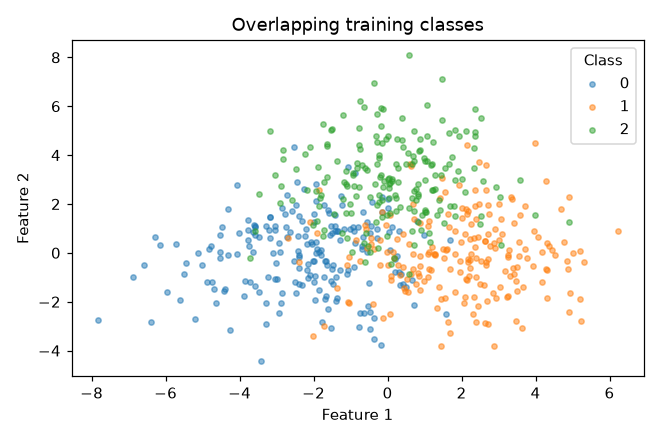

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
for class_id in range(3):
    class_points = train_features[train_labels == class_id]
    ax.scatter(class_points[:, 0], class_points[:, 1], s=12, alpha=0.5, label=class_id)

ax.set(xlabel="Feature 1", ylabel="Feature 2", title="Overlapping training classes")
ax.legend(title="Class")
fig.tight_layout()
plt.show()

## 2. Fit the classifier

Logistic regression gives each point three class probabilities, with columns
corresponding to labels 0, 1 and 2. These are the starting scores for LAC; a high
probability alone is not a guarantee that a prediction is correct.

In [4]:
model = LogisticRegression()
model.fit(train_features, train_labels)

calibration_probabilities = model.predict_proba(calibration_features)
test_probabilities = model.predict_proba(test_features)

print("First test probabilities:", test_probabilities[0].round(3))
print("True class:", test_labels[0])

First test probabilities: [0.002 0.994 0.004]
True class: 1


## 3. Learn the LAC threshold

For a calibration example, LAC measures how surprising the **known correct
label** was: its score is `1 - probability of the correct label`. A small score
means the classifier gave that answer a high probability.

With `alpha = 0.10`, the coverage target is 90%. The conformal quantile chooses
a threshold from these scores, including the finite-sample correction.
Calibration adjusts this threshold, not the classifier's weights.

In [5]:
alpha = 0.10
calibration_scores = lac_scores(calibration_probabilities, calibration_labels)
threshold = conformal_quantile(calibration_scores, alpha)

first_true_label = calibration_labels[0]
first_true_probability = calibration_probabilities[0, first_true_label]

print(f"First calibration label: {first_true_label}")
print(f"Probability of that label: {first_true_probability:.3f}")
print(f"LAC score: 1 - {first_true_probability:.3f} = {calibration_scores[0]:.3f}")
print(f"Learned score threshold: {threshold:.3f}")

First calibration label: 2
Probability of that label: 0.985
LAC score: 1 - 0.985 = 0.015
Learned score threshold: 0.828


## 4. Build sets and decide when to act

For a new point we do not know the correct answer, so we score **every candidate
label**. LAC includes each label whose score is at most the learned threshold.

A one-label set leads to an automatic prediction. Larger sets are ambiguous;
an empty set means no label passed the threshold. Both are deferred.

In [6]:
prediction_sets = lac_prediction_sets(test_probabilities, threshold)
automated = singleton_mask(prediction_sets)
predictions = test_probabilities.argmax(axis=1)

# Inspect a few points before summarising the whole test set.
for index in range(4):
    included_labels = np.flatnonzero(prediction_sets[index]).tolist()
    decision = "automate" if automated[index] else "review"
    print(f"True class: {test_labels[index]} | set: {included_labels} | {decision}")

True class: 1 | set: [1] | automate
True class: 2 | set: [0, 2] | review
True class: 0 | set: [0] | automate
True class: 1 | set: [1, 2] | review


## 5. Check what the decisions mean

- **Coverage** counts how often the prediction set contains the true class,
  whether or not we automate.
- **Average set size** describes how many possible answers remain.
- **Automation rate** is the fraction of examples with a one-label set.
- **Automated error** counts mistakes only among those automatic decisions.

The last two measures describe the routing trade-off; they are not the same
quantity as coverage.

In [7]:
coverage = empirical_coverage(prediction_sets, test_labels)
mean_set_size = average_set_size(prediction_sets)
automatic_fraction = automation_rate(automated)
automatic_error = automated_error_rate(predictions, test_labels, automated)

error_text = "N/A" if np.isnan(automatic_error) else f"{automatic_error:.1%}"
print(f"Coverage: {coverage:.1%}")
print(f"Average set size: {mean_set_size:.2f}")
print(f"Automation rate: {automatic_fraction:.1%}")
print(f"Automated error: {error_text}")

Coverage: 92.3%
Average set size: 1.49
Automation rate: 58.0%
Automated error: 8.0%


## Takeaway

The shortlist lets us defer ambiguous points instead of forcing a single answer.
A covered example can still need review, and a one-label set can still be wrong:
the 90% target concerns **set coverage**, not 90% accuracy among automatic decisions.

Under the unchanged sampling process used here, conformal coverage holds on
average over new calibration samples and new examples. A single run need not
land exactly at 90%; this notebook illustrates the procedure rather than
verifying that guarantee.

Next, [apply the same steps to BANKING77 text requests](../banking77_tfidf/01_lac_routing.ipynb).